<a href="https://colab.research.google.com/github/JosephBless/Deep-Learning-Colab/blob/main/Chap_6%EF%BC%9A%E5%8B%95%E9%87%8F%E7%AD%96%E7%95%A5%E3%80%81%E5%9D%87%E5%80%BC%E5%9B%9E%E6%AD%B8%E7%AD%96%E7%95%A5%E8%88%87%E6%8A%80%E8%A1%93%E6%8C%87%E6%A8%99%E7%AD%96%E7%95%A5%E9%96%8B%E7%99%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install backtrader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.0 MB/s eta 0:00:00


過去幾天我們分別學習了基本均線指標來交易以及使用 `Backtrader`來做回測，今天我們將綜合學習**動量策略**、**均值回歸策略**，以及利用**技術指標（如 RSI 和 MACD）**開發交易策略，並且會使用 `Backtrader` 框架進行策略的**回測**與**優化**。我們將從這些策略的數學基礎開始，逐步完成策略的開發與優化。

### **一、動量策略開發**

#### **1. 動量策略的概念與數學基礎**
動量策略基於這樣的假設：價格在一段時間內將會繼續沿著目前的趨勢運行，即 `強者恆強，弱者恆弱`。在統計學上，這代表資產價格呈現出自相關性。

- **基本思想**：如果過去 N 天資產的價格持續上漲，未來一段時間可能會繼續上漲；反之亦然。
- **常用指標**：N 日動量指標、收益率排序等。

**動量公式**：
$$
Momentum_t = P_t - P_{t-N}
$$
其中，$ P_t $ 是第 $ t $ 天的收盤價，$ P_{t-N} $ 是 $ N $ 天前的收盤價。動量策略根據該值的正負判斷買入或賣出信號。

#### **2. 使用 Backtrader 實現動量策略**

[*********************100%***********************]  1 of 1 completed


初始資金: 100000.00
回測後的資金: 100028.62
夏普比率: -33.46
最大回撤: -0.03%


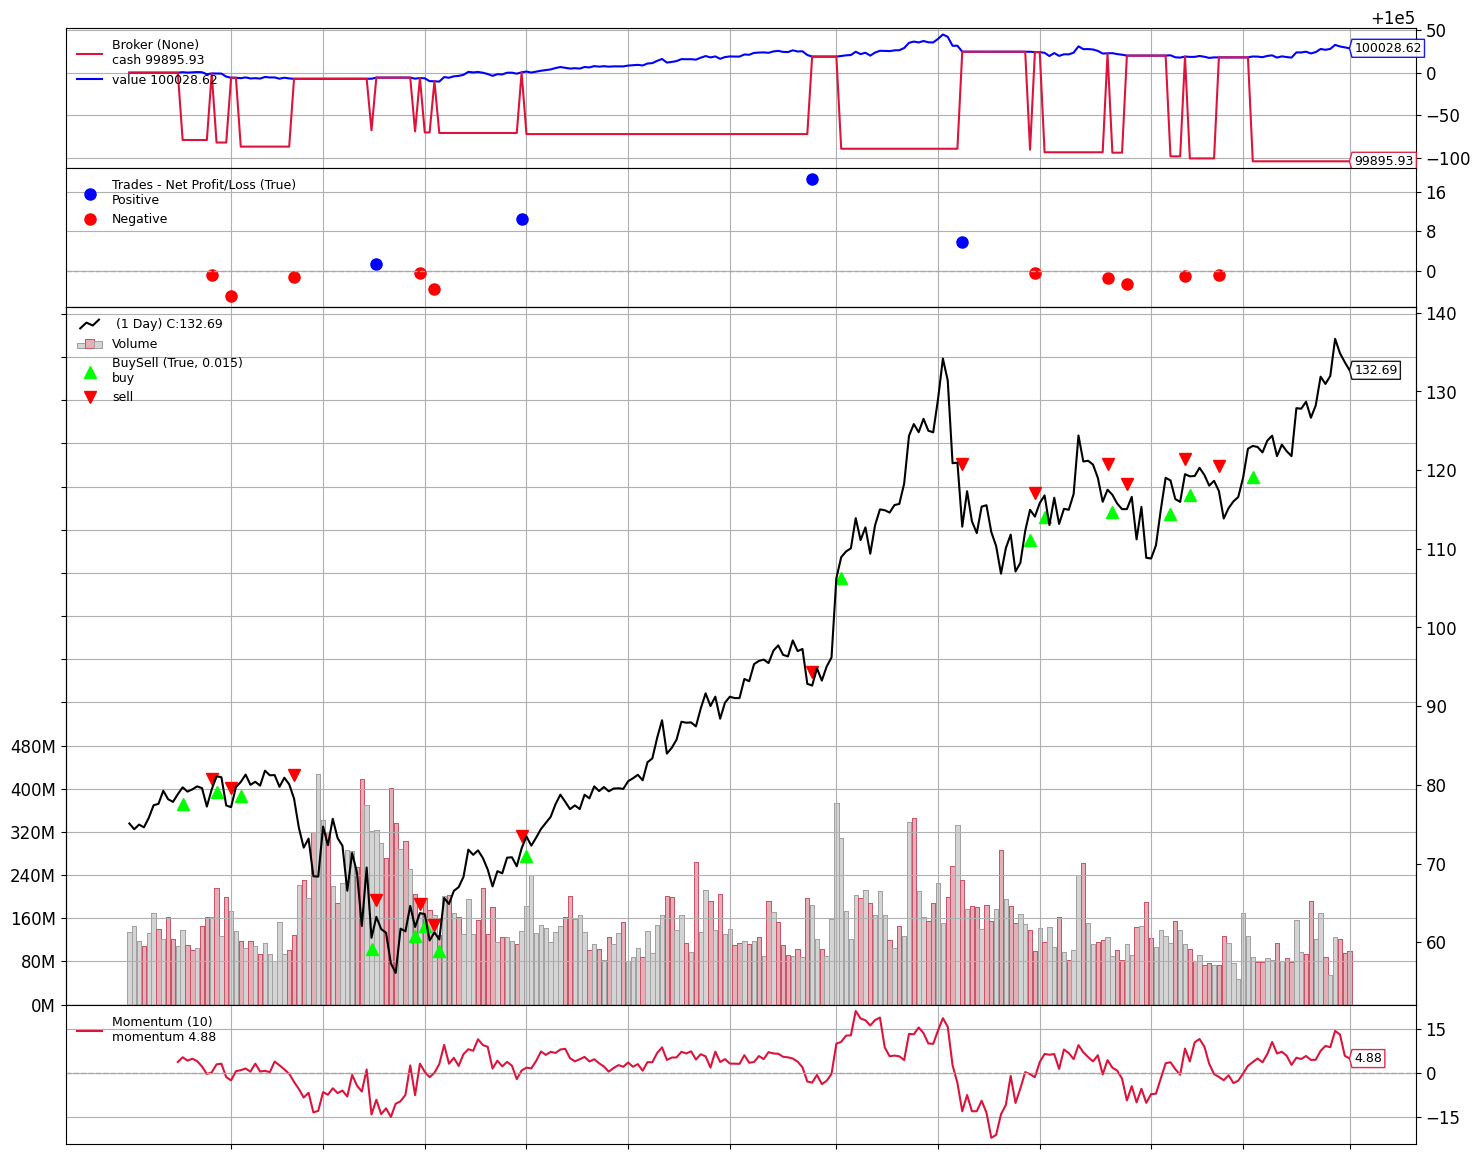

In [ ]:
import backtrader as bt
import yfinance as yf
import pandas as pd
import numpy as np

# 使用 yfinance 下載 AAPL 的數據
data = yf.download('AAPL', start='2020-01-01', end='2021-01-01')

# 將數據轉換為 backtrader 可以使用的格式
data_bt = bt.feeds.PandasData(dataname=data)

# 建立動量策略類別
class MomentumStrategy(bt.Strategy):
    params = (('period', 10),)

    def __init__(self):
        self.momentum = bt.indicators.Momentum(self.data.close, period=self.params.period)
        self.starting_value = self.broker.getvalue()
        self.daily_values = []  # 用於儲存每日資產價值

    def next(self):
        if not self.position:  # 如果沒有持倉
            if self.momentum[0] > 0:  # 動量指標大於0，表示上升趨勢
                self.buy()
        elif self.momentum[0] <= 0:  # 動量指標小於等於0，表示下降趨勢
            self.sell()

        # 每次更新時記錄當天的資產價值
        self.daily_values.append(self.broker.getvalue())

# 設定回測環境
cerebro = bt.Cerebro()
cerebro.addstrategy(MomentumStrategy)

# 添加數據到 backtrader
cerebro.adddata(data_bt)

# 設定初始資金
cerebro.broker.setcash(100000)

# 執行回測
print(f'初始資金: {cerebro.broker.getvalue():.2f}')
results = cerebro.run()
print(f'回測後的資金: {cerebro.broker.getvalue():.2f}')

# 取得策略結果
strategy = results[0]

# 計算每日收益率
portfolio_values = pd.Series(strategy.daily_values)
returns = portfolio_values.pct_change().dropna()

# 計算年化夏普比率
annual_return = returns.mean() * 252
annual_volatility = returns.std() * np.sqrt(252)
risk_free_rate = 0.01  # 無風險利率設為1%
sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

# 計算最大回撤
cumulative_returns = (1 + returns).cumprod()
drawdown = cumulative_returns / cumulative_returns.cummax() - 1
max_drawdown = drawdown.min()

print(f'夏普比率: {sharpe_ratio:.2f}')
print(f'最大回撤: {max_drawdown:.2%}')

# 繪製圖表
## 如果在 local machine python terminal 之上:
# cerebro.plot()

## 如果在 Colab 之上:
#https://www.roelpeters.be/how-to-use-backtrader-plots-in-python-notebooks/
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = [15, 12]
plt.rcParams.update({'font.size': 12})
img = cerebro.plot(iplot = False)
img[0][0].savefig('backtrader_momentum.png')

### **二、均值回歸策略開發**

#### **1. 均值回歸策略的概念與數學基礎**
均值回歸策略基於這樣一種假設：價格圍繞某個均值上下波動，當價格偏離均值過多時，具有回歸的趨勢。在統計學上，這意味著價格的時間序列具有均值回歸性質。

- **基本思想**：當價格高於均值時，預期價格將下跌至均值；當價格低於均值時，預期價格將回升至均值。
- **常用指標**：均線乖離率、Z-score 等。

**Z-score 公式**：
$$
Z\text{-score}_t = \frac{P_t - \mu_t}{\sigma_t}
$$
其中，$ P_t $ 是當前價格，$ \mu_t $ 是移動平均值，$ \sigma_t $ 是移動標準差。當 Z-score 大於某個閾值時，產生賣出信號；當 Z-score 小於某個閾值時，產生買入信號。

#### **2. 使用 Backtrader 實現均值回歸策略**

[*********************100%***********************]  1 of 1 completed


初始資金: 100000.00
回測後的資金: 99999.71
夏普比率: -36.93
最大回撤: -0.02%


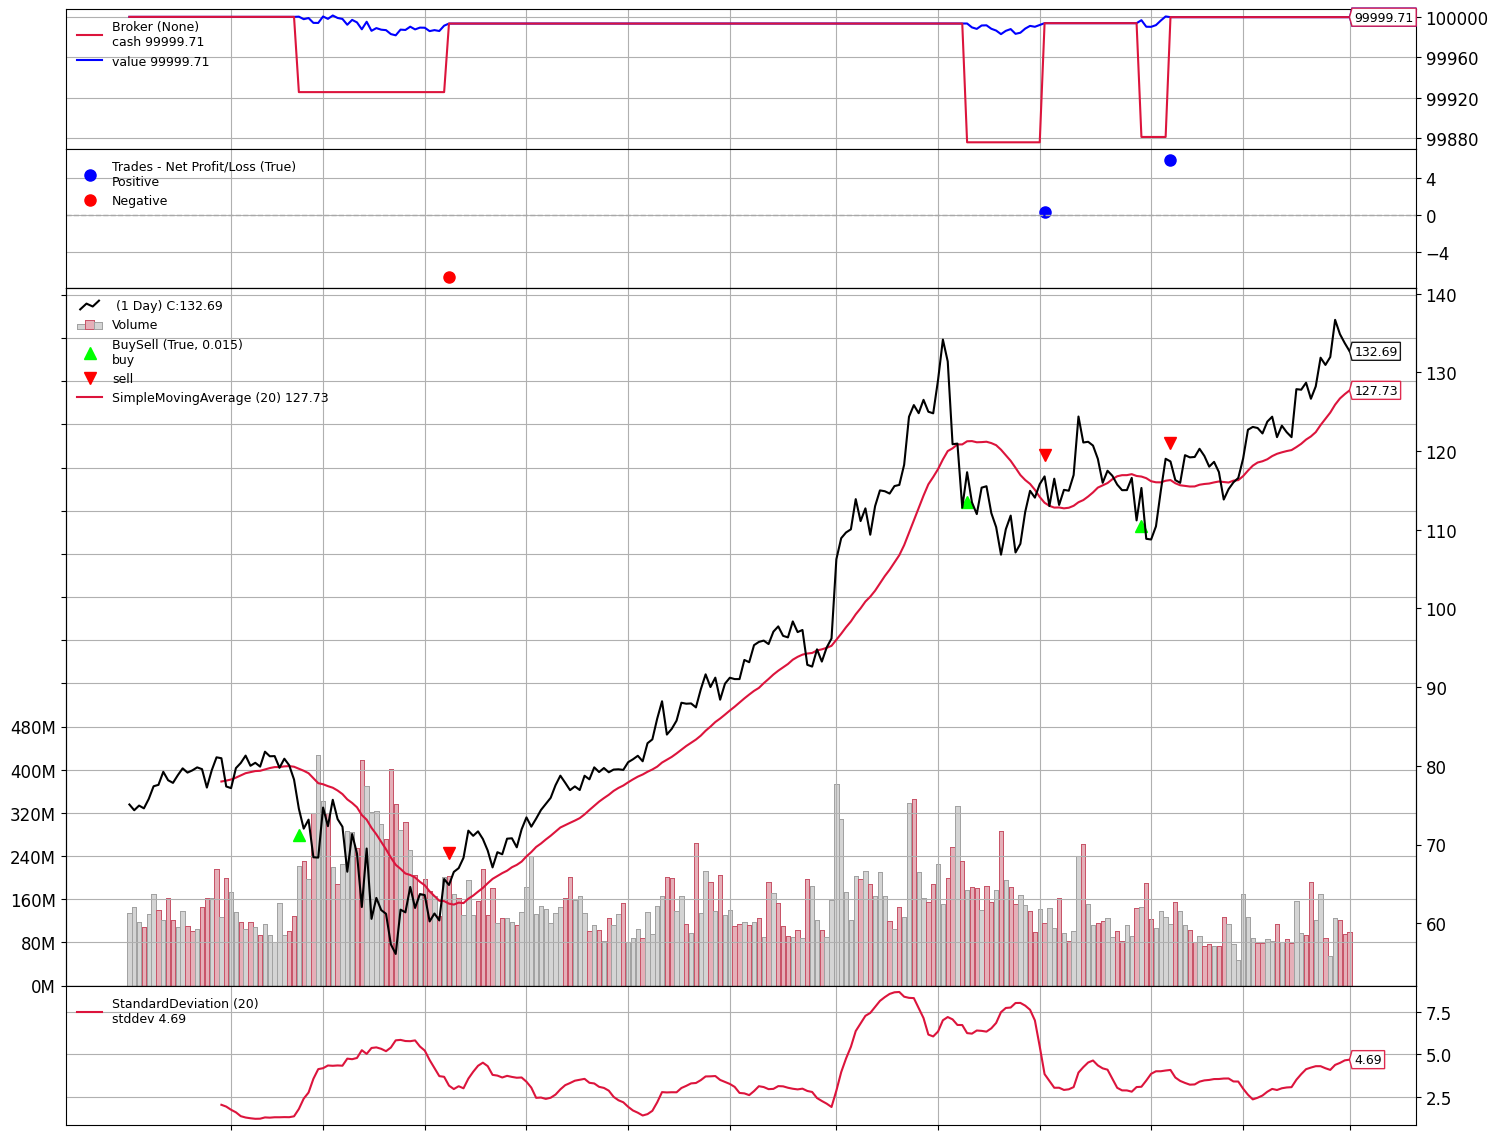

In [ ]:
import backtrader as bt
import yfinance as yf
import pandas as pd
import numpy as np

# 使用 yfinance 下載 AAPL 的數據
data = yf.download('AAPL', start='2020-01-01', end='2021-01-01')

# 將數據轉換為 backtrader 可以使用的格式
data_bt = bt.feeds.PandasData(dataname=data)

#均值回歸策略
class MeanReversionStrategy(bt.Strategy):
    params = (('period', 20), ('zscore_entry', 1), ('zscore_exit', 0))

    def __init__(self):
        self.moving_avg = bt.indicators.SimpleMovingAverage(self.data.close, period=self.params.period)
        self.stddev = bt.indicators.StandardDeviation(self.data.close, period=self.params.period)
        self.zscore = (self.data.close - self.moving_avg) / self.stddev
        self.daily_values = []  # 用於儲存每日資產價值

    def next(self):
        if self.zscore[0] < -self.params.zscore_entry and not self.position:
            self.buy()
        elif self.zscore[0] > self.params.zscore_exit and self.position:
            self.sell()

        # 每次更新時記錄當天的資產價值
        self.daily_values.append(self.broker.getvalue())

# 設定回測環境
cerebro = bt.Cerebro()
cerebro.addstrategy(MeanReversionStrategy)

# 添加數據到 backtrader
cerebro.adddata(data_bt)

# 設定初始資金
cerebro.broker.setcash(100000)

# 執行回測
print(f'初始資金: {cerebro.broker.getvalue():.2f}')
results = cerebro.run()
print(f'回測後的資金: {cerebro.broker.getvalue():.2f}')

# 取得策略結果
strategy = results[0]

# 計算每日收益率
portfolio_values = pd.Series(strategy.daily_values)
returns = portfolio_values.pct_change().dropna()

# 計算年化夏普比率
annual_return = returns.mean() * 252
annual_volatility = returns.std() * np.sqrt(252)
risk_free_rate = 0.01  # 無風險利率設為1%
sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

# 計算最大回撤
cumulative_returns = (1 + returns).cumprod()
drawdown = cumulative_returns / cumulative_returns.cummax() - 1
max_drawdown = drawdown.min()

print(f'夏普比率: {sharpe_ratio:.2f}')
print(f'最大回撤: {max_drawdown:.2%}')

# 繪製圖表
## 如果在 local machine python terminal 之上:
# cerebro.plot()

## 如果在 Colab 之上:
#https://www.roelpeters.be/how-to-use-backtrader-plots-in-python-notebooks/
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = [15, 12]
plt.rcParams.update({'font.size': 12})
img = cerebro.plot(iplot = False)
img[0][0].savefig('backtrader_z_scores.png')

### **三、技術指標策略開發**

#### **1. RSI 策略**

##### **RSI 的數學基礎**
相對強弱指標（RSI）衡量價格變動的速度和幅度，計算公式為：
$$
RSI = 100 - \frac{100}{1 + RS}
$$
其中，$ RS $ 為平均上漲收益與平均下跌收益之比。通常，RSI 超過 70 表示超買，低於 30 表示超賣。

**使用 Backtrader 實現 RSI 策略**：

[*********************100%***********************]  1 of 1 completed


初始資金: 100000.00
回測後的資金: 100018.25
夏普比率: -42.15
最大回撤: -0.02%


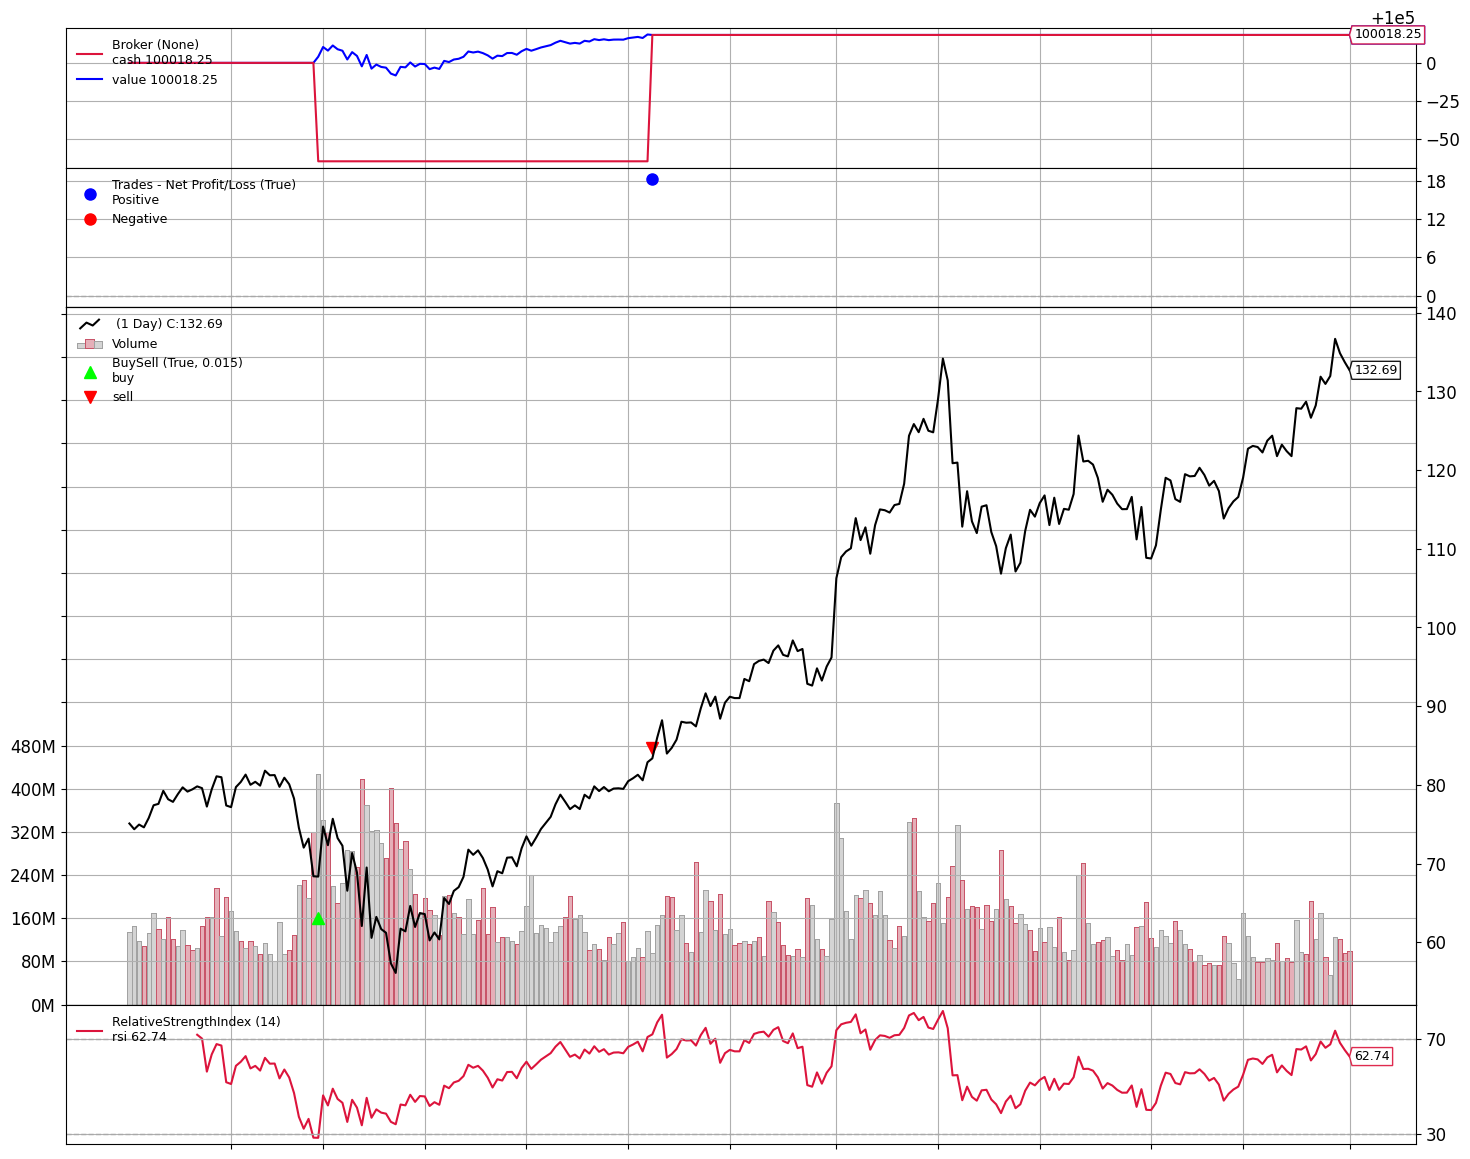

In [ ]:
import backtrader as bt
import yfinance as yf
import pandas as pd
import numpy as np

# 使用 yfinance 下載 AAPL 的數據
data = yf.download('AAPL', start='2020-01-01', end='2021-01-01')

# 將數據轉換為 backtrader 可以使用的格式
data_bt = bt.feeds.PandasData(dataname=data)

#RSI策略
class RSIStrategy(bt.Strategy):
    params = (('rsi_period', 14), ('rsi_overbought', 70), ('rsi_oversold', 30))

    def __init__(self):
        self.rsi = bt.indicators.RelativeStrengthIndex(self.data.close, period=self.params.rsi_period)
        self.daily_values = []  # 用於儲存每日資產價值

    def next(self):
        if self.rsi < self.params.rsi_oversold and not self.position:
            self.buy()
        elif self.rsi > self.params.rsi_overbought and self.position:
            self.sell()

        # 每次更新時記錄當天的資產價值
        self.daily_values.append(self.broker.getvalue())

# 設定回測環境
cerebro = bt.Cerebro()
cerebro.addstrategy(RSIStrategy)

# 添加數據到 backtrader
cerebro.adddata(data_bt)

# 設定初始資金
cerebro.broker.setcash(100000)

# 執行回測
print(f'初始資金: {cerebro.broker.getvalue():.2f}')
results = cerebro.run()
print(f'回測後的資金: {cerebro.broker.getvalue():.2f}')

# 取得策略結果
strategy = results[0]

# 計算每日收益率
portfolio_values = pd.Series(strategy.daily_values)
returns = portfolio_values.pct_change().dropna()

# 計算年化夏普比率
annual_return = returns.mean() * 252
annual_volatility = returns.std() * np.sqrt(252)
risk_free_rate = 0.01  # 無風險利率設為1%
sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

# 計算最大回撤
cumulative_returns = (1 + returns).cumprod()
drawdown = cumulative_returns / cumulative_returns.cummax() - 1
max_drawdown = drawdown.min()

print(f'夏普比率: {sharpe_ratio:.2f}')
print(f'最大回撤: {max_drawdown:.2%}')

# 繪製圖表
## 如果在 local machine python terminal 之上:
# cerebro.plot()

## 如果在 Colab 之上:
#https://www.roelpeters.be/how-to-use-backtrader-plots-in-python-notebooks/
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = [15, 12]
plt.rcParams.update({'font.size': 12})
img = cerebro.plot(iplot = False)
img[0][0].savefig('backtrader_rsi.png')

#### **2. MACD 策略**

##### **MACD 的數學基礎**
MACD 是利用兩條不同周期的指數移動平均線（EMA）的差值來衡量價格動量，計算公式為：
$$
MACD = EMA_{x} - EMA_{y}
$$
$x$ 與 $y$ 分別為不同長度的時間。其中，例如常見的訊號線為 $MACD$ 的 9 日 EMA。當 $MACD$ 上穿訊號線時，產生買入信號；下穿時，產生賣出信號。

**使用 Backtrader 實現 MACD 策略**：

[*********************100%***********************]  1 of 1 completed


初始資金: 100000.00
回測後的資金: 100041.18
夏普比率: -33.37
最大回撤: -0.02%


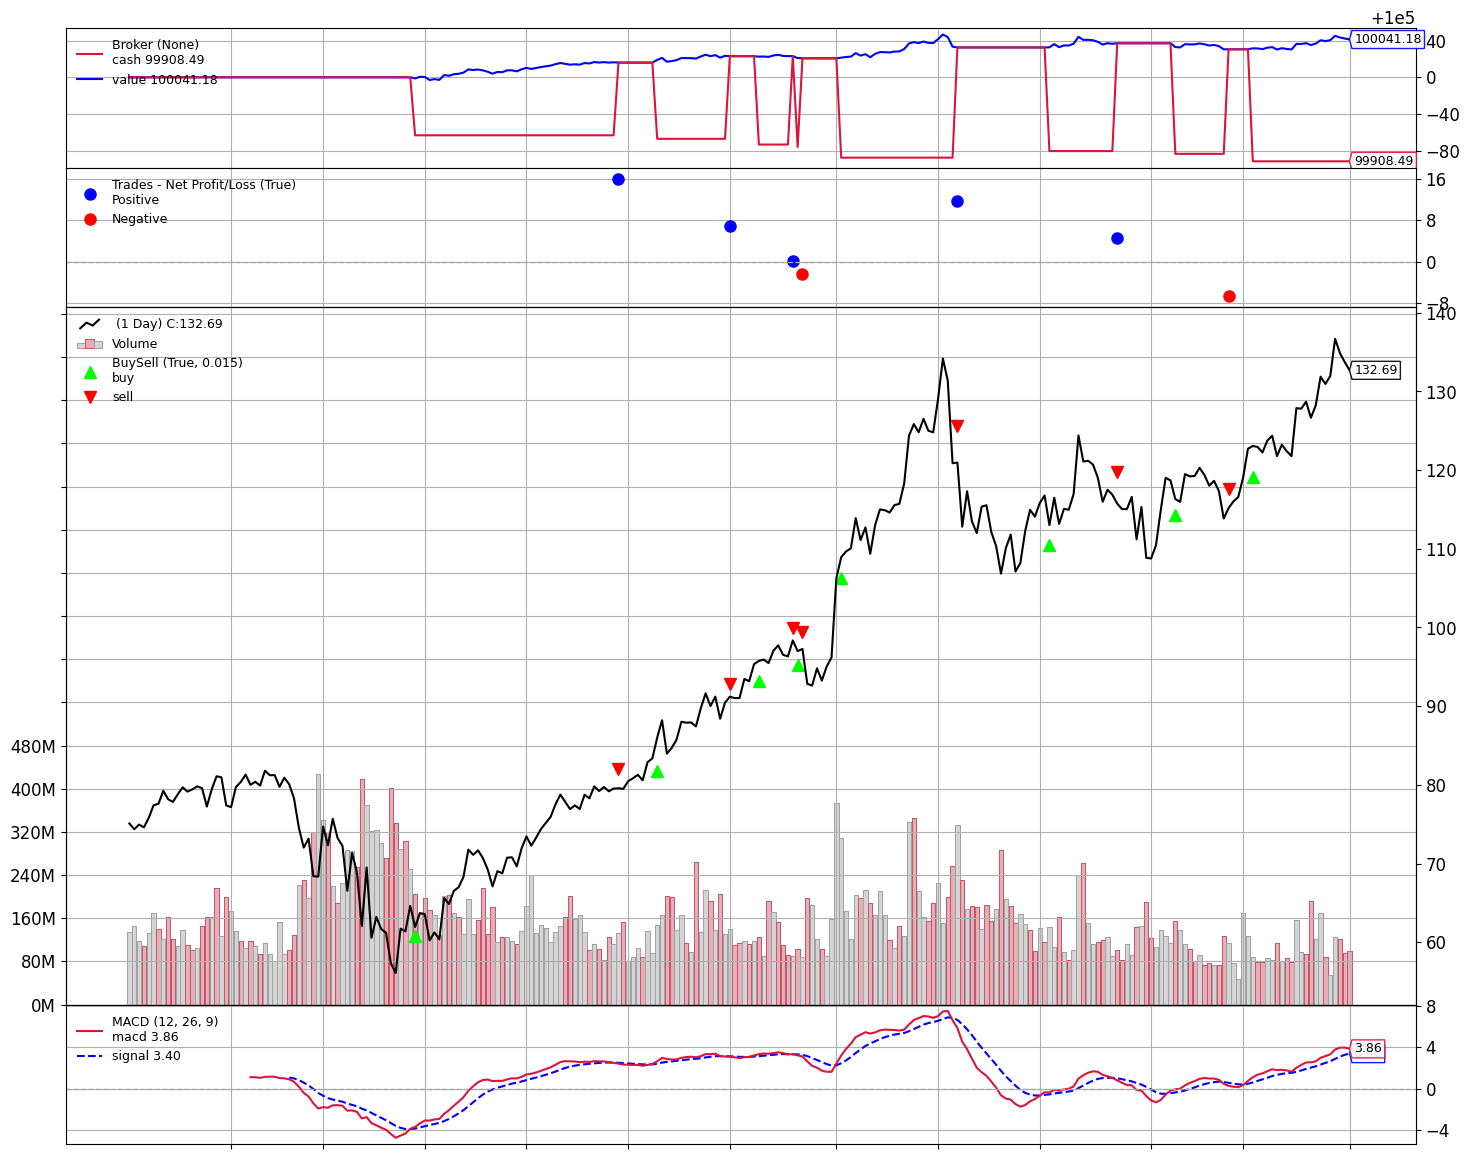

In [ ]:
import backtrader as bt
import yfinance as yf
import pandas as pd
import numpy as np

# 使用 yfinance 下載 AAPL 的數據
data = yf.download('AAPL', start='2020-01-01', end='2021-01-01')

# 將數據轉換為 backtrader 可以使用的格式
data_bt = bt.feeds.PandasData(dataname=data)

#MACD策略
class MACDStrategy(bt.Strategy):
    def __init__(self):
        self.macd = bt.indicators.MACD(self.data.close)
        self.signal = self.macd.signal
        self.daily_values = []  # 用於儲存每日資產價值

    def next(self):
        if self.macd.macd[0] > self.signal[0] and not self.position:
            self.buy()
        elif self.macd.macd[0] < self.signal[0] and self.position:
            self.sell()

        # 每次更新時記錄當天的資產價值
        self.daily_values.append(self.broker.getvalue())


# 設定回測環境
cerebro = bt.Cerebro()
cerebro.addstrategy(MACDStrategy)

# 添加數據到 backtrader
cerebro.adddata(data_bt)

# 設定初始資金
cerebro.broker.setcash(100000)

# 執行回測
print(f'初始資金: {cerebro.broker.getvalue():.2f}')
results = cerebro.run()
print(f'回測後的資金: {cerebro.broker.getvalue():.2f}')

# 取得策略結果
strategy = results[0]

# 計算每日收益率
portfolio_values = pd.Series(strategy.daily_values)
returns = portfolio_values.pct_change().dropna()

# 計算年化夏普比率
annual_return = returns.mean() * 252
annual_volatility = returns.std() * np.sqrt(252)
risk_free_rate = 0.01  # 無風險利率設為1%
sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

# 計算最大回撤
cumulative_returns = (1 + returns).cumprod()
drawdown = cumulative_returns / cumulative_returns.cummax() - 1
max_drawdown = drawdown.min()

print(f'夏普比率: {sharpe_ratio:.2f}')
print(f'最大回撤: {max_drawdown:.2%}')

# 繪製圖表
## 如果在 local machine python terminal 之上:
# cerebro.plot()

## 如果在 Colab 之上:
#https://www.roelpeters.be/how-to-use-backtrader-plots-in-python-notebooks/
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = [15, 12]
plt.rcParams.update({'font.size': 12})
img = cerebro.plot(iplot = False)
img[0][0].savefig('backtrader_macd.png')

### **四、策略優化與參數調整**

使用 `Backtrader` 可以對策略參數進行優化，以找到最佳的參數組合。例如，可以對 MaCross 策略進行優化，尋找最適合的 MaCross 週期和超買、超賣閾值。
**對 MaCross 策略進行參數優化**：

In [ ]:
!pip install qgrid

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.2/889.2 kB 16.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Using cached jedi-0.19.1-py2.py3-none-any.whl.metadata (22 kB)
Using cached jedi-0.19.1-py2.py3-none-any.whl (1.6 MB)
  Created wheel for qgrid: filename=qgrid-1.3.1-py2.py3-none-any.whl size=1761252 sha256=b02b28e830125ba4140f94c1915a407793a333867be56130b325c2b477717b69
  Stored in directory: /root/.cache/pip/wheels/b2/28/9b/c1053eb92a506d814e21f415d6ce4beab694a3efed99b500bc
Successfully built qgrid


In [ ]:
import backtrader as bt
import backtrader.analyzers as btanalyzers
import pandas as pd
import matplotlib
from datetime import datetime
import qgrid

class MaCrossStrategy(bt.Strategy):

    params = (
        ('fast_length', 10),
        ('slow_length', 50)
    )

    def __init__(self):
        ma_fast = bt.ind.SMA(period = self.params.fast_length)
        ma_slow = bt.ind.SMA(period = self.params.slow_length)

        self.crossover = bt.ind.CrossOver(ma_fast, ma_slow)

    def next(self):
        if not self.position:
            if self.crossover > 0:
                self.buy()
        elif self.crossover < 0:
            self.close()

cerebro = bt.Cerebro()

# 使用 yfinance 下載 AAPL 的數據
data = yf.download('AAPL', start='2020-01-01', end='2021-01-01')

# 將數據轉換為 backtrader 可以使用的格式
data_bt = bt.feeds.PandasData(dataname=data)

cerebro.adddata(data_bt)



strats = cerebro.optstrategy(
        MaCrossStrategy,
        fast_length = range(1, 11),
        slow_length = range(25, 76, 5))


cerebro.broker.setcash(1000000.0)

cerebro.addsizer(bt.sizers.PercentSizer, percents = 10)
cerebro.addanalyzer(btanalyzers.SharpeRatio, _name = "sharpe")
cerebro.addanalyzer(btanalyzers.DrawDown, _name = "drawdown")
cerebro.addanalyzer(btanalyzers.Returns, _name = "returns")

back = cerebro.run()

par_list = [[x[0].params.fast_length,
             x[0].params.slow_length,
             x[0].analyzers.returns.get_analysis()['rnorm100'],
             x[0].analyzers.drawdown.get_analysis()['max']['drawdown'],
             x[0].analyzers.sharpe.get_analysis()['sharperatio']
            ] for x in back]

par_df = pd.DataFrame(par_list, columns = ['length_fast', 'length_slow', 'return', 'dd', 'sharpe'])

qgrid.show_grid(par_df)

ModuleNotFoundError: No module named 'backtrader'

In [ ]:
par_df

,length_fast,length_slow,return,dd,sharpe
0,1,25,6.366260,2.695606,None
1,1,30,6.902647,4.151988,None
2,1,35,5.963844,4.601810,None
3,1,40,5.738081,4.612691,None
4,1,45,5.819275,4.291790,None
...,...,...,...,...,...
105,10,55,7.110246,3.545331,None
106,10,60,6.681391,3.429858,None
107,10,65,6.211139,3.446298,None
108,10,70,5.763243,3.513028,None
